In [3]:
import pandas as pd
from google.colab import files

# Upload file manually
uploaded = files.upload()

Saving crop_selection_risk_dataset.xlsx to crop_selection_risk_dataset.xlsx


In [4]:
df = pd.read_excel('crop_selection_risk_dataset.xlsx')

df.head()

,Crop Type,Rainfall (mm),Temperature (°C),Soil Moisture (%),Irrigation Delay (Days),Fertilizer Usage,Humidity (%),Climate Risk,Water Availability Score,Pest Risk Level,Predicted Risk
0,Rice,850,28,78,1,Medium,82,Low,9,Low,Low Risk
1,Wheat,420,24,45,5,High,60,Medium,6,Medium,Medium Risk
2,Maize,300,31,30,8,High,48,High,4,High,High Risk
3,Sugarcane,920,27,82,2,Medium,85,Low,9,Low,Low Risk
4,Pulses,250,34,25,10,Low,42,High,3,High,High Risk


In [5]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Crop Type                 10 non-null     object
 1   Rainfall (mm)             10 non-null     int64 
 2   Temperature (°C)          10 non-null     int64 
 3   Soil Moisture (%)         10 non-null     int64 
 4   Irrigation Delay (Days)   10 non-null     int64 
 5   Fertilizer Usage          10 non-null     object
 6   Humidity (%)              10 non-null     int64 
 7   Climate Risk              10 non-null     object
 8   Water Availability Score  10 non-null     int64 
 9   Pest Risk Level           10 non-null     object
 10  Predicted Risk            10 non-null     object
dtypes: int64(6), object(5)
memory usage: 1012.0+ bytes
None
       Rainfall (mm)  Temperature (°C)  Soil Moisture (%)  \
count       10.00000         10.000000          10.000000   
mean       48

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'Crop Type',
    'Fertilizer Usage',
    'Climate Risk',
    'Pest Risk Level'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features
X = df.drop('Predicted Risk', axis=1)

# Target
y = le.fit_transform(df['Predicted Risk'])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
predictions = model.predict(X_test)

print(predictions)

[0 2]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


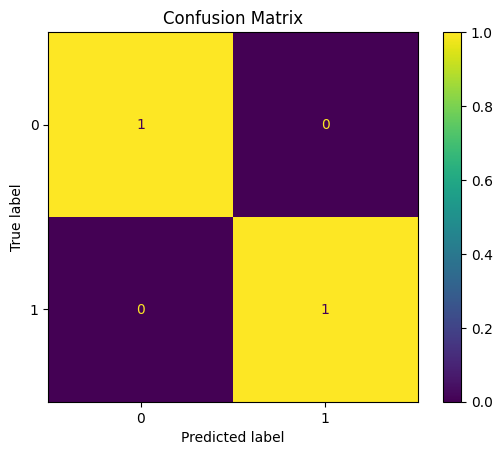

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

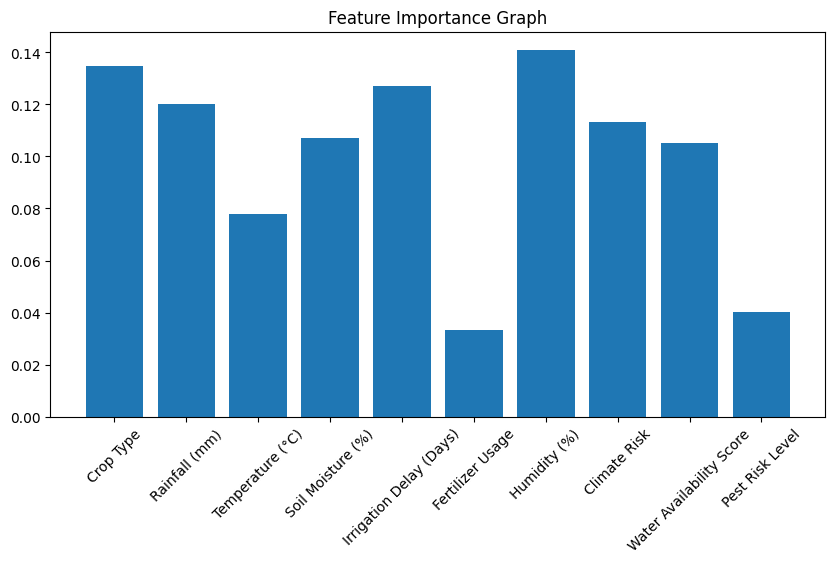

In [12]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance Graph")

plt.show()

In [13]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

results.head(10)

,Actual,Predicted
0,0,0
1,2,2


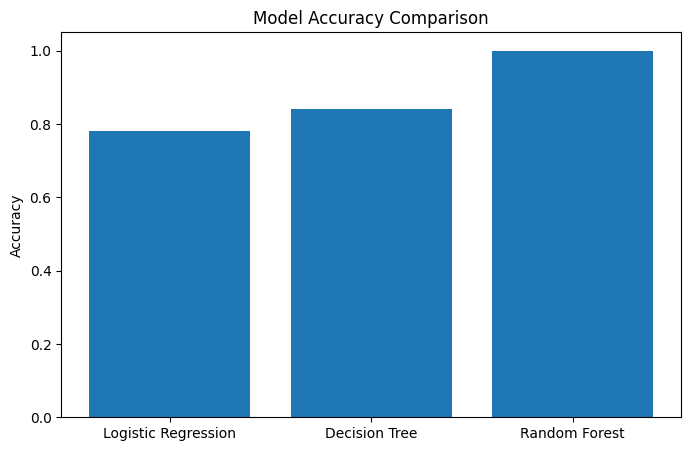

In [14]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [0.78, 0.84, accuracy]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel('Accuracy')

plt.title('Model Accuracy Comparison')

plt.show()